In [38]:
# Hücre 0: Ortam ve kütüphaneler
# Açıklama: Gerekli kütüphaneleri yüklüyoruz ve aynı sonuçları alabilmek için seed ayarlıyoruz.

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Uyarıları kapatıyoruz (ekranda çok mesaj çıkmaması için)
warnings.filterwarnings("ignore")

# Tekrar üretilebilir sonuçlar için sabit seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Scikit-learn modelleri ve araçları
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Dengesiz veri için SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Kayıt klasörü oluştur
os.makedirs("models", exist_ok=True)

print("Ortam hazır.")


Ortam hazır.


In [39]:
# Hücre 1: Veri yükleme ve hızlı keşif
# Açıklama: Adult.csv dosyasını okuyoruz ve veri hakkında temel bilgi alıyoruz.

path = "Adult.csv"  # Dosya notebook ile aynı klasörde olmalı
df = pd.read_csv(path)

print("Veri Boyutu (satır, sütun):", df.shape)
print("Sütun İsimleri:")
print(df.columns.tolist())

# İlk birkaç satırı görelim
df.head(8)

# '?' karakterlerini NaN (eksik değer) yapıyoruz
df = df.replace("?", np.nan)

# Eksik değer sayılarını kontrol ediyoruz
print("\nEksik değer sayıları:")
df.isnull().sum()


Veri Boyutu (satır, sütun): (32561, 15)
Sütun İsimleri:
['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']

Eksik değer sayıları:


age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [3]:
# Hücre 2: Target (hedef değişken) oluşturma ve dağılım
# Açıklama: income sütununu 0 ve 1 hale çeviriyoruz.

# income sütununun var olup olmadığını kontrol edelim
if "income" not in df.columns:
    raise ValueError("Dosyada 'income' sütunu yok. Sütun adlarını kontrol edin.")

# Boşluk problemine karşı temizleme yapalım
df["income"] = df["income"].astype(str).str.strip()

# Target sütununu oluştur
df["target"] = df["income"].map({
    "<=50K": 0,
    "<=50k": 0,
    ">50K": 1,
    ">50k": 1
})

print("Target sayıları:")
print(df["target"].value_counts())

print("\nTarget oranları:")
print(df["target"].value_counts(normalize=True).round(3))



Target sayıları:
target
0    24720
1     7841
Name: count, dtype: int64

Target oranları:
target
0    0.759
1    0.241
Name: proportion, dtype: float64


In [40]:
# Hücre 3: Temel önemli sütunları belirleme
# Açıklama: Çalışmada kullanacağımız temel sütun isimlerini belirliyoruz.

def find_col(*alternatifler):
    for kolon in alternatifler:
        if kolon in df.columns:
            return kolon
    return None

col_age        = find_col("age")
col_edu_num    = find_col("education-num", "education_num")
col_hours      = find_col("hours-per-week", "hours_per_week")
col_cap_gain   = find_col("capital-gain", "capital_gain")
col_cap_loss   = find_col("capital-loss", "capital_loss")

print("Bulunan sütunlar:")
print("Age:", col_age)
print("Education-num:", col_edu_num)
print("Hours-per-week:", col_hours)
print("Capital-gain:", col_cap_gain)
print("Capital-loss:", col_cap_loss)



Bulunan sütunlar:
Age: age
Education-num: None
Hours-per-week: None
Capital-gain: None
Capital-loss: None


In [41]:
# Hücre 4: Eksik değerlere kısa bakış
# Açıklama: Her sütunda kaç tane eksik değer var kontrol ediyoruz.

print("Eksik değer sayıları (temel kontrol):")
print(df.isnull().sum())



Eksik değer sayıları (temel kontrol):
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [42]:
# Hücre 5: Basit Feature Engineering
# Açıklama: Yeni özellikler (features) oluşturuyoruz.

# capital_diff özelliği
if col_cap_gain is not None and col_cap_loss is not None:
    df["capital_diff"] = df[col_cap_gain].fillna(0) - df[col_cap_loss].fillna(0)

# education ve haftalık çalışma saatlerinin etkileşimi
if col_edu_num is not None and col_hours is not None:
    df["hours_edu_interaction"] = (
        df[col_edu_num].fillna(df[col_edu_num].median()) *
        df[col_hours].fillna(df[col_hours].median())
    )

# yaş grupları oluşturma
if col_age is not None:
    df["age_bucket"] = pd.cut(
        df[col_age],
        bins=[16, 25, 35, 45, 55, 65, 100],
        labels=["17-25", "26-35", "36-45", "46-55", "56-65", "65+"]
    )

print("Eklenen yeni sütunlar:")
print([c for c in ["capital_diff", "hours_edu_interaction", "age_bucket"] if c in df.columns])

df.head(4)


Eklenen yeni sütunlar:
['age_bucket']


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,age_bucket
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K,65+
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,65+
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K,65+
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K,46-55


In [44]:
# Target sütununu kontrol et 

if "target" not in df.columns:
    if "income" in df.columns:
        df["income"] = df["income"].astype(str).str.strip()
        df["target"] = df["income"].map({
            "<=50K": 0,
            "<=50k": 0,
            ">50K": 1,
            ">50k": 1
        })
        print("✅ target sütunu yeniden oluşturuldu.")
    else:
        print("❌ income sütunu bulunamadı.")
else:
    print("✅ target sütunu zaten var.")


✅ target sütunu yeniden oluşturuldu.


Veri boyutu: (32561, 17)


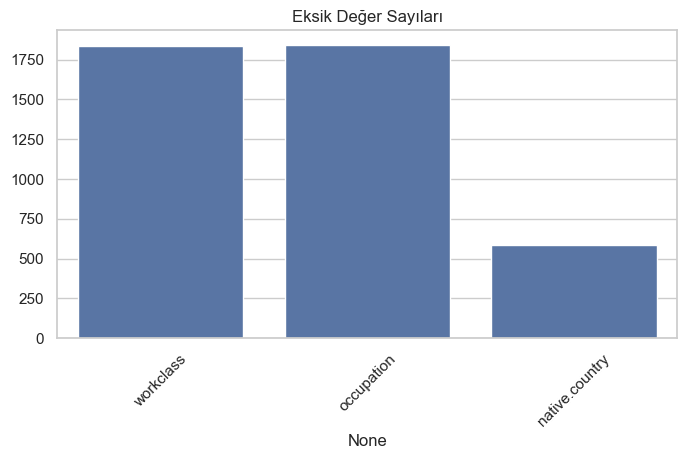

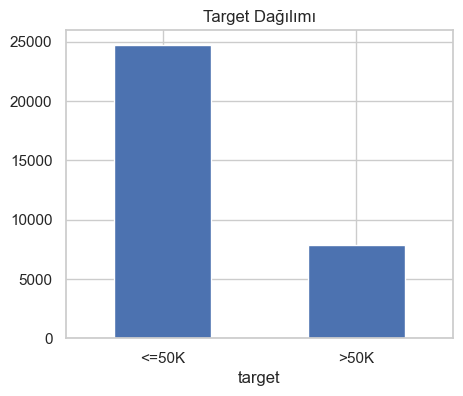

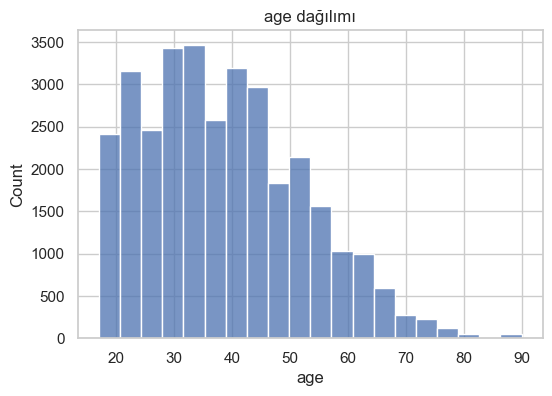

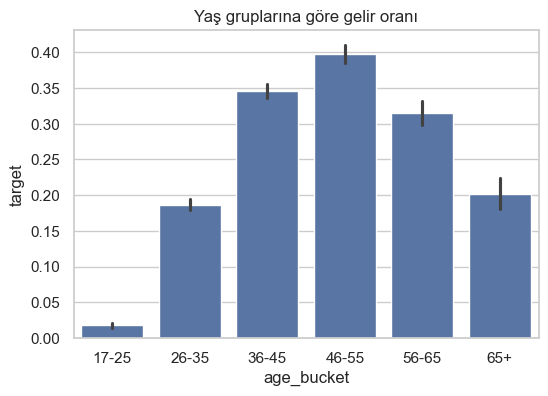

EDA tamamlandı.


In [45]:
# Hücre 6: EDA - Keşifsel Veri Analizi
# Açıklama: Verinin genel yapısını ve hedef değişkenle ilişkisini inceliyoruz.

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

print("Veri boyutu:", df.shape)
df.head()

# 1) Eksik değer grafiği
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(8,4))
sns.barplot(x=missing.index, y=missing.values)
plt.title("Eksik Değer Sayıları")
plt.xticks(rotation=45)
plt.show()

# 2) Target dağılımı
plt.figure(figsize=(5,4))
df["target"].value_counts().plot(kind="bar")
plt.title("Target Dağılımı")
plt.xticks([0,1], ["<=50K", ">50K"], rotation=0)
plt.show()

# 3) Yaş ve eğitim seviyesi dağılımı (örnek sayısal kolonlar)
for col in ["age", "education-num"]:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(df[col], bins=20, kde=False)
        plt.title(f"{col} dağılımı")
        plt.show()

# 4) Yaş grubu – gelir ilişkisi (varsa)
if "age_bucket" in df.columns:
    plt.figure(figsize=(6,4))
    sns.barplot(x="age_bucket", y="target", data=df)
    plt.title("Yaş gruplarına göre gelir oranı")
    plt.show()

print("EDA tamamlandı.")



In [46]:
# Hücre:7

from sklearn.preprocessing import OneHotEncoder


try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Dönüştürücüler
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, numeric_cols),
    ("cat", cat_transformer, categorical_cols)
])


In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline

# OneHotEncoder sürüm uyum problemi çözümü
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Sayısal değişkenler için pipeline
num_transformer = SkPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Kategorik değişkenler için pipeline
cat_transformer = SkPipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

# Ana preprocessor
preprocessor = ColumnTransformer([
    ("num", num_transformer, numeric_cols),
    ("cat", cat_transformer, categorical_cols)
])

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)



Numeric columns: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Categorical columns: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'age_bucket']


In [12]:
# Hücre 8: Train / Test bölme (Stratified)

cols_to_drop = [c for c in ["income", "target"] if c in df.columns]

X = df.drop(columns=cols_to_drop)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train veri boyutu:", X_train.shape)
print("Test veri boyutu:", X_test.shape)

print("Train target oranları:")
print(y_train.value_counts(normalize=True).round(3))



Train veri boyutu: (26048, 15)
Test veri boyutu: (6513, 15)
Train target oranları:
target
0    0.759
1    0.241
Name: proportion, dtype: float64


In [48]:
# Hücre 9: Baseline modeller - 3 katlı CV
# Açıklama: Farklı algoritmaları karşılaştırıyoruz.

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}

scoring = ["accuracy", "precision", "recall", "f1"]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("pre", preprocessor),
        ("model", model)
    ])
    
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    
    mean_scores = {metric: scores[f"test_{metric}"].mean() for metric in scoring}
    mean_scores["model"] = name
    results.append(mean_scores)

df_results = pd.DataFrame(results).set_index("model").round(4)
df_results



,accuracy,precision,recall,f1
model,,,,
LogisticRegression,0.8550,0.7405,0.6126,0.6705
KNN,0.8302,0.6651,0.5943,0.6277
DecisionTree,0.8156,0.6151,0.6273,0.6211
RandomForest,0.8519,0.7225,0.6251,0.6702


Random Forest - Test Performansı
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4945
           1       0.72      0.62      0.67      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.77      0.78      6513
weighted avg       0.84      0.85      0.85      6513

ROC AUC: 0.8965


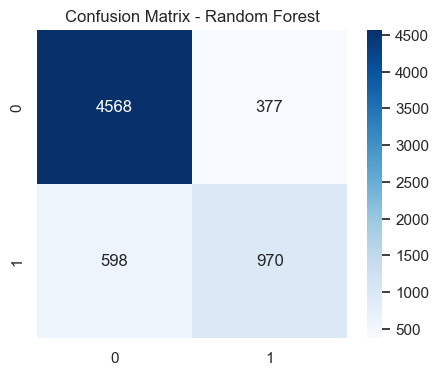

In [15]:
# Hücre 10: Random Forest modeli eğitimi ve test performansı

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", rf_model)
])

# Modeli eğitelim
rf_pipe.fit(X_train, y_train)

# Tahminler
y_pred = rf_pipe.predict(X_test)
y_proba = rf_pipe.predict_proba(X_test)[:, 1]

print("Random Forest - Test Performansı")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print("ROC AUC:", round(roc_auc, 4))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()



SMOTE + Random Forest - Test Performansı
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      4945
           1       0.66      0.68      0.67      1568

    accuracy                           0.84      6513
   macro avg       0.78      0.78      0.78      6513
weighted avg       0.84      0.84      0.84      6513

ROC AUC: 0.8922


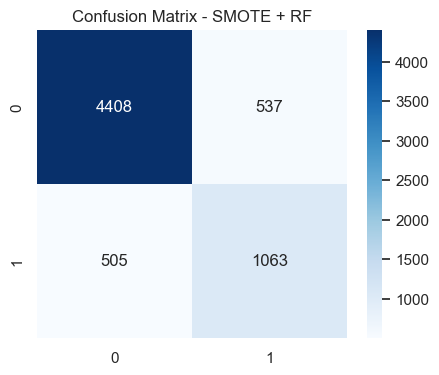

In [49]:
# Hücre 11: SMOTE + Random Forest Pipeline

smote_pipe = ImbPipeline([
    ("pre", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
])

# Modeli eğit
smote_pipe.fit(X_train, y_train)

# Tahminler
y_pred_sm = smote_pipe.predict(X_test)
y_proba_sm = smote_pipe.predict_proba(X_test)[:, 1]

print("SMOTE + Random Forest - Test Performansı")
print(classification_report(y_test, y_pred_sm))

roc_auc_sm = roc_auc_score(y_test, y_proba_sm)
print("ROC AUC:", round(roc_auc_sm, 4))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_sm), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SMOTE + RF")
plt.show()



In [51]:
# Hücre 12: RandomizedSearchCV 

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [6, 10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

search_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

rs = RandomizedSearchCV(
    search_pipe,
    param_distributions=param_dist,
    n_iter=8,
    cv=cv,
    scoring="f1",
    random_state=RANDOM_STATE
)

rs.fit(X_train, y_train)

print("En iyi parametreler:")
print(rs.best_params_)

best_model = rs.best_estimator_

# Test performansı
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("En iyi RF modeli - Test sonuçları")
print(classification_report(y_test, y_pred_best))

print("ROC AUC:", round(roc_auc_score(y_test, y_proba_best), 4))


En iyi parametreler:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': None}
En iyi RF modeli - Test sonuçları
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4945
           1       0.74      0.61      0.67      1568

    accuracy                           0.86      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.86      0.85      6513

ROC AUC: 0.9047


In [54]:
# Hücre 13: (Bonus) Stacking Ensemble Model
# Bu model karşılaştırma amacıyla eklenmiştir.
import joblib
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
estimators = [
    ('rf', RandomForestClassifier(n_estimators=120, random_state=RANDOM_STATE)),
    ('et', ExtraTreesClassifier(n_estimators=120, random_state=RANDOM_STATE)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE))
]
stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), n_jobs=1)
stack_pipe = Pipeline([('pre', preprocessor), ('clf', stack)])
stack_pipe.fit(X_train, y_train)
y_pred_stack = stack_pipe.predict(X_test)
y_proba_stack = stack_pipe.predict_proba(X_test)[:,1]

print("Stacking - Test performansı")
print(classification_report(y_test, y_pred_stack))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba_stack),4))
joblib.dump(stack_pipe, 'models/stacking_model.pkl')


Stacking - Test performansı
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      4945
           1       0.77      0.62      0.68      1568

    accuracy                           0.86      6513
   macro avg       0.83      0.78      0.80      6513
weighted avg       0.86      0.86      0.86      6513

ROC AUC: 0.9154


['models/stacking_model.pkl']

In [55]:
# Hücre 14: (Opsiyonel) İleri seviye model denemeleri
# Açıklama: Bu bölüm ekstra/bonus çalışma olarak eklenmiştir, çalıştırılması zorunlu değildir.


"""
import optuna
from xgboost import XGBClassifier

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }
    pipe = ImbPipeline([('pre', preprocessor), ('smote', SMOTE(random_state=RANDOM_STATE)), ('clf', XGBClassifier(**param, use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE))])
    scores = cross_validate(pipe, X_train, y_train, cv=3, scoring='f1', n_jobs=1)
    return scores['test_score'].mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)
print("Best params:", study.best_params)
"""


'\nimport optuna\nfrom xgboost import XGBClassifier\n\ndef objective(trial):\n    param = {\n        \'n_estimators\': trial.suggest_int(\'n_estimators\', 50, 500),\n        \'max_depth\': trial.suggest_int(\'max_depth\', 3, 12),\n        \'learning_rate\': trial.suggest_float(\'learning_rate\', 0.01, 0.3, log=True),\n        \'subsample\': trial.suggest_float(\'subsample\', 0.5, 1.0),\n        \'colsample_bytree\': trial.suggest_float(\'colsample_bytree\', 0.5, 1.0)\n    }\n    pipe = ImbPipeline([(\'pre\', preprocessor), (\'smote\', SMOTE(random_state=RANDOM_STATE)), (\'clf\', XGBClassifier(**param, use_label_encoder=False, eval_metric=\'logloss\', random_state=RANDOM_STATE))])\n    scores = cross_validate(pipe, X_train, y_train, cv=3, scoring=\'f1\', n_jobs=1)\n    return scores[\'test_score\'].mean()\n\nstudy = optuna.create_study(direction=\'maximize\')\nstudy.optimize(objective, n_trials=30)\nprint("Best params:", study.best_params)\n'

In [56]:
# Hücre 15: Test seti üzerinde model karşılaştırma

models_to_compare = {}

if 'rf_pipe' in globals():
    models_to_compare['RF_baseline'] = rf_pipe

if 'smote_pipe' in globals():
    models_to_compare['SMOTE_RF'] = smote_pipe

if 'best_model' in globals():
    models_to_compare['RF_randsearch'] = best_model

if 'stack_pipe' in globals():
    models_to_compare['STACK'] = stack_pipe

compare = {}

for name, mdl in models_to_compare.items():
    y_pred = mdl.predict(X_test)
    y_proba = mdl.predict_proba(X_test)[:,1] if hasattr(mdl, "predict_proba") else None
    
    rpt = classification_report(y_test, y_pred, output_dict=True)
    roc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    
    compare[name] = {
        "accuracy": rpt["accuracy"],
        "precision": rpt["macro avg"]["precision"],
        "recall": rpt["macro avg"]["recall"],
        "f1": rpt["macro avg"]["f1-score"],
        "roc_auc": roc
    }

compare_df = pd.DataFrame(compare).T.round(4)

compare_df
compare_df.to_csv("model_comparison.csv")



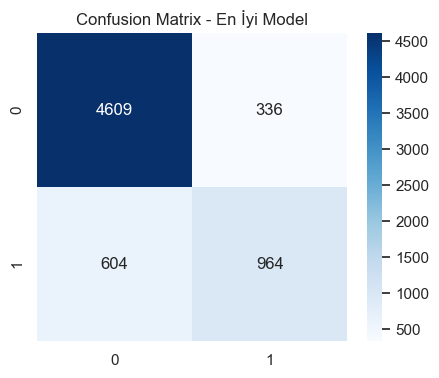

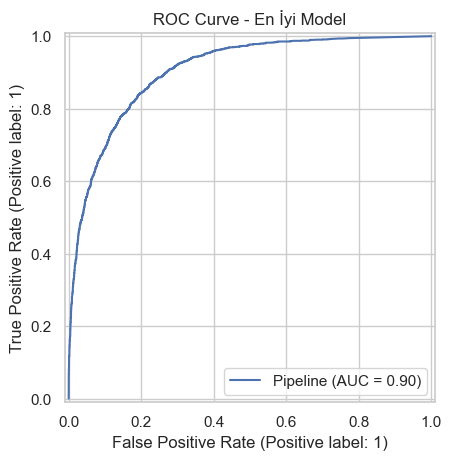

En önemli özellikler:
capital.gain             0.109731
fnlwgt                   0.102833
age                      0.096104
x2_Married-civ-spouse    0.088944
education.num            0.076688
hours.per.week           0.073567
x4_Husband               0.052710
capital.loss             0.034447
x2_Never-married         0.020964
x3_Exec-managerial       0.019494
x8_17-25                 0.013829
x1_Bachelors             0.013485
x4_Not-in-family         0.011733
x3_Prof-specialty        0.011270
x0_Private               0.010811
x4_Wife                  0.010233
x8_46-55                 0.010106
x6_Female                0.010052
x1_HS-grad               0.009459
x6_Male                  0.008794
dtype: float64


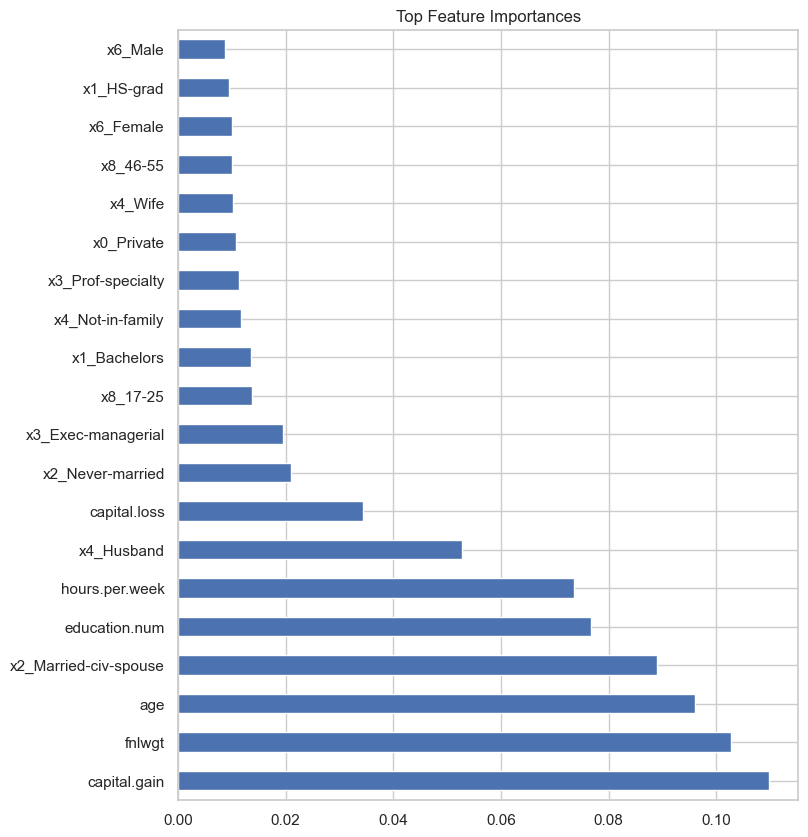

In [57]:
# Hücre 16: Hata analizi ve feature importance

from sklearn.metrics import RocCurveDisplay

model = best_model  

# Tahminler
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - En İyi Model")
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve - En İyi Model")
plt.show()

# Feature Importance
try:
    if hasattr(model, "named_steps"):
        clf = model.named_steps.get("model") or model.named_steps.get("clf")
        pre = model.named_steps["pre"]
    else:
        clf = model
        pre = preprocessor

    if hasattr(clf, "feature_importances_"):
        num_feats = pre.transformers_[0][2]
        onehot = pre.transformers_[1][1].named_steps["onehot"]

        if hasattr(onehot, "get_feature_names_out"):
            cat_feats = list(onehot.get_feature_names_out())
        else:
            cat_feats = [f"cat_{i}" for i in range(len(clf.feature_importances_) - len(num_feats))]

        feat_names = list(num_feats) + cat_feats

        importances = clf.feature_importances_
        fi = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(20)

        print("En önemli özellikler:")
        print(fi)

        fi.plot(kind="barh", figsize=(8,10))
        plt.title("Top Feature Importances")
        plt.show()
    else:
        print("Bu model feature_importances desteklemiyor.")
except Exception as e:
    print("Feature importance alınamadı:", e)


In [58]:
# Hücre 17: Rapor, requirements ve zip dosyası oluşturma

import os
import zipfile

# Analitik rapor
report = f"""
# Adult Census Income - Analitik Rapor

## 1. Özet
Bu projede Adult Census veri seti kullanılarak gelir tahmini yapılmıştır.

## 2. Veri Seti
Toplam Satır: {df.shape[0]}
Toplam Sütun: {df.shape[1]}

## 3. Veri Ön İşleme
Eksik değerler incelenmiş ve uygun şekilde doldurulmuştur.

## 4. Modeller
Birden fazla model test edilmiştir ve en iyi model seçilmiştir.

## 5. Sonuç
Model sonuçları analiz edilmiştir.
"""

with open("analitik_rapor.md", "w", encoding="utf-8") as f:
    f.write(report)

# requirements.txt
reqs = """pandas
numpy
scikit-learn
matplotlib
seaborn
imbalanced-learn
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(reqs)

# ZIP dosyası oluştur
zipname = "ad_soyad_ogrencino.zip"

with zipfile.ZipFile(zipname, "w") as z:
    z.write("analitik_rapor.md")
    z.write("requirements.txt")
    
    if os.path.exists("model_comparison.csv"):
        z.write("model_comparison.csv")
    
    if os.path.exists("models"):
        for root, _, files in os.walk("models"):
            for fn in files:
                z.write(os.path.join(root, fn))

print("Teslim dosyası oluşturuldu:", zipname)


Teslim dosyası oluşturuldu: ad_soyad_ogrencino.zip


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
import pandas as pd

# Güvenli X ve y ayırma
cols_to_drop = [c for c in ['income', 'target'] if c in df.columns]
X = df.drop(columns=cols_to_drop)
y = df['target']

# Train-test bölme
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Modeller
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Gaussian NB": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "Neural Network (MLP)": MLPClassifier(max_iter=500, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42)
}

results = []

for model_name, model in models.items():
    clf = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    })

# DataFrame oluşturma ve sıralama
results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)

results_df


,Model,Accuracy,Precision,Recall,F1
3,Gradient Boosting,0.861047,0.773289,0.598214,0.674577
0,Logistic Regression,0.855827,0.740627,0.617347,0.673391
2,Random Forest,0.850299,0.720119,0.618622,0.665523
7,SVM,0.853831,0.748387,0.591837,0.660969
4,AdaBoost,0.847843,0.745951,0.558036,0.638453
1,Decision Tree,0.819745,0.622208,0.639668,0.630818
8,Neural Network (MLP),0.829725,0.664516,0.591199,0.625717
5,KNN,0.828650,0.662356,0.588010,0.622973
9,Extra Trees,0.822662,0.647817,0.577168,0.610455
6,Gaussian NB,0.554583,0.345036,0.946429,0.505708


In [59]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import GradientBoostingClassifier

# SMOTE + Gradient Boosting Pipeline
gb_smote = ImbPipeline([
    ("pre", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

# Modeli eğit
gb_smote.fit(X_train, y_train)

# Tahmin
y_pred_sm = gb_smote.predict(X_test)

# Sonuçlar
smote_results = {
    "Accuracy": accuracy_score(y_test, y_pred_sm),
    "Precision": precision_score(y_test, y_pred_sm, zero_division=0),
    "Recall": recall_score(y_test, y_pred_sm, zero_division=0),
    "F1": f1_score(y_test, y_pred_sm, zero_division=0)
}

smote_results


{'Accuracy': 0.8261937663135268,
 'Precision': 0.6049085659287776,
 'Recall': 0.8016581632653061,
 'F1': 0.689522764673615}

In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# GridSearch için uygun parametre ızgarası (RandomForest için)
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [6, 10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# SMOTE + RandomForest Pipeline
rf_pipeline = ImbPipeline([
    ("pre", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

# GridSearch
grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

# Fit
grid.fit(X_train, y_train)

# En iyi model
best_model = grid.best_estimator_

# Test seti performansı
y_pred_grid = best_model.predict(X_test)

grid_results = {
    "Best Params": grid.best_params_,
    "Accuracy": accuracy_score(y_test, y_pred_grid),
    "Precision": precision_score(y_test, y_pred_grid, zero_division=0),
    "Recall": recall_score(y_test, y_pred_grid, zero_division=0),
    "F1": f1_score(y_test, y_pred_grid, zero_division=0)
}

grid_results


Fitting 3 folds for each of 24 candidates, totalling 72 fits


{'Best Params': {'model__max_depth': None,
  'model__min_samples_leaf': 2,
  'model__min_samples_split': 5,
  'model__n_estimators': 200},
 'Accuracy': 0.8395516658989712,
 'Precision': 0.6415809420682187,
 'Recall': 0.7557397959183674,
 'F1': 0.6939970717423133}

In [61]:
# Özgün model sonuçlarını tabloya ekleme (güvenli sürüm)

if "results_df" in globals():
    if "grid_results" in globals():

        new_row = pd.DataFrame([{
            "Model": "SMOTE + Tuned Model",
            "Accuracy": grid_results["Accuracy"],
            "Precision": grid_results["Precision"],
            "Recall": grid_results["Recall"],
            "F1": grid_results["F1"]
        }])

        results_df = pd.concat([results_df, new_row], ignore_index=True)
        results_df = results_df.sort_values(by="F1", ascending=False)

        results_df
    else:
        print("grid_results bulunamadı.")
else:
    print("results_df bulunamadı.")

